<a href="https://colab.research.google.com/github/mvashi-sonic/AICapstoneProj/blob/dev/capstone_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Do this and restart to get rid of the annoying error, restart after

In [1]:
!pip uninstall -y torchvision

Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128


Mount the drive

In [1]:
from google.colab import drive

# 1. Mount your Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


Load Dataset

In [2]:
import os
os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"

import torch

!pip install datasets
from datasets import load_dataset
from datasets import Dataset


data = load_dataset(
    "json",
    #data_files="/content/drive/MyDrive/capstone_usable_qa_data/all_records.json"
    data_files="/content/drive/MyDrive/AI_capstone_training_data/all_records_final_formatted_without_metadata.json"
)
#print(type(data))
#print(data.keys() if isinstance(data, dict) else "Not a dictionary")
records = data["train"]["All_Records"]

for record in records:
    record["label"] = int(record["label"])
    del record["label"]
dataset = Dataset.from_list(records)

#dataset = Dataset.from_list(data["train"]["All_Records"])
#print (dataset.column_names)

Generating train split: 0 examples [00:00, ? examples/s]

Test, Train, Validation Split

In [3]:
#Test Train Split
from datasets import DatasetDict

# 2. First split: Isolate the final test set (15%)
train_testvalid = dataset.train_test_split(test_size=0.15, seed=42)

# 3. Second split: Split the temporary training set into train (70%) and validation (15%)
test_valid = train_testvalid["train"].train_test_split(test_size=0.176, seed=42)

# 4. Combine everything into a clean DatasetDict
final_dataset = DatasetDict({
    "train": test_valid["train"],
    "validation": test_valid["test"],  # The 'test' of the second split is your validation set
    "test": train_testvalid["test"]
})

print(len(test_valid["train"]))
print(len(test_valid["test"]))
print(len(train_testvalid["test"]))

87504
18691
18741


Finbert and Tokenizer

In [4]:
#Load Finbert
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.


...

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: downloading bytes:           |  0.00B            

[transformers] BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Tokenize Function

In [5]:
#Tokenize
def tokenize(example):

    return tokenizer(
        example["question"],
        example["reference"],
        truncation=True,
        padding="max_length",
        #padding=False,
        max_length=512
    )

Tokenize

In [6]:
#print(test_valid["train"].column_names)

train_ds = test_valid["train"].map(tokenize, batched=True)
valid_ds = train_testvalid["test"].map(tokenize, batched=True)




Map:   0%|          | 0/87504 [00:00<?, ? examples/s]

Map:   0%|          | 0/18741 [00:00<?, ? examples/s]

'train_ds = train_ds.remove_columns([\n    "question",\n    "reference",\n    "ticker",\n    "section"\n])\n\nvalid_ds = valid_ds.remove_columns([\n    "question",\n    "reference",\n    "ticker",\n    "section"\n])'

In [7]:
train_ds.set_format("torch")
valid_ds.set_format("torch")

Update Column Name For Pytorch

In [8]:
train_ds = train_ds.rename_column("label", "labels")
valid_ds = valid_ds.rename_column("label", "labels")

In [9]:
columns = [
    "input_ids",
    "attention_mask",
    "token_type_ids",
    "labels"
]


train_ds.set_format(
    type="torch",
    columns=columns
)

valid_ds.set_format(
    type="torch",
    columns=columns
)

Convert Labels To Int

In [10]:
def fix_labels(example):
    return {
        "labels": int(example["labels"])
    }

train_ds = train_ds.map(fix_labels)
valid_ds = valid_ds.map(fix_labels)

Map:   0%|          | 0/87504 [00:00<?, ? examples/s]

Map:   0%|          | 0/18741 [00:00<?, ? examples/s]

DataLoader

In [11]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=8
)

batch = next(iter(train_loader))

for k, v in batch.items():
    print(k, type(v))

labels <class 'torch.Tensor'>
input_ids <class 'torch.Tensor'>
token_type_ids <class 'torch.Tensor'>
attention_mask <class 'torch.Tensor'>


In [12]:
import torch
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [13]:
from torch.optim import AdamW
optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

Train The Model

In [14]:
from tqdm.auto import tqdm
#print(batch)

EPOCHS = 3

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    progress = tqdm(train_loader)

    for batch in progress:
        #for k, v in batch.items():
         # print(k, type(v))
        # Move tensors to GPU
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)

        loss = outputs.loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        progress.set_description(
            f"Epoch {epoch+1}"
        )

        progress.set_postfix(
            loss=loss.item()
        )

    print(
        f"Training Loss: {total_loss/len(train_loader):.4f}"
    )

  0%|          | 0/10938 [00:00<?, ?it/s]

Training Loss: 0.0526


  0%|          | 0/10938 [00:00<?, ?it/s]

Training Loss: 0.0246


  0%|          | 0/10938 [00:00<?, ?it/s]

Training Loss: 0.0157


Save The Model

In [15]:
model.save_pretrained(
    "finbert_relevance_mv_final_3_without"
)

tokenizer.save_pretrained(
    "finbert_relevance_mv_final_3_without"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('finbert_relevance_mv_final_3_without/tokenizer_config.json',
 'finbert_relevance_mv_final_3_without/tokenizer.json')

Load the Saved Model

In [16]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification


"""tokenizer = AutoTokenizer.from_pretrained(
    "/content/drive/MyDrive/AI_Capstone_Model_Final/3_Epochs_without/finbert_relevance_mv_final_3_without"
)

model = AutoModelForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/AI_Capstone_Model_Final/3_Epochs_without/finbert_relevance_mv_final_3_without"
)"""
tokenizer = AutoTokenizer.from_pretrained(
    "./finbert_relevance_mv_final_3_without"
)

model = AutoModelForSequenceClassification.from_pretrained(
    "./finbert_relevance_mv_final_3_without"
)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [17]:
model = model.to(device)
print("Model device:")
print(next(model.parameters()).device)


Model device:
cuda:0


In [18]:
model.eval()

predictions = []
probabilities = []
true_labels = []

with torch.no_grad():

    for batch in valid_loader:

        labels = batch["labels"]

        inputs = {
            k: v.to(device)
            for k, v in batch.items()
            if k != "labels"
        }

        outputs = model(**inputs)

        probs = torch.softmax(
            outputs.logits,
            dim=1
        )

        preds = torch.argmax(
            probs,
            dim=1
        )

        predictions.extend(
            preds.cpu().numpy()
        )

        probabilities.extend(
            probs[:,1].cpu().numpy()
        )

        true_labels.extend(
            labels.numpy()
        )

ROC-AUC: 0.9994


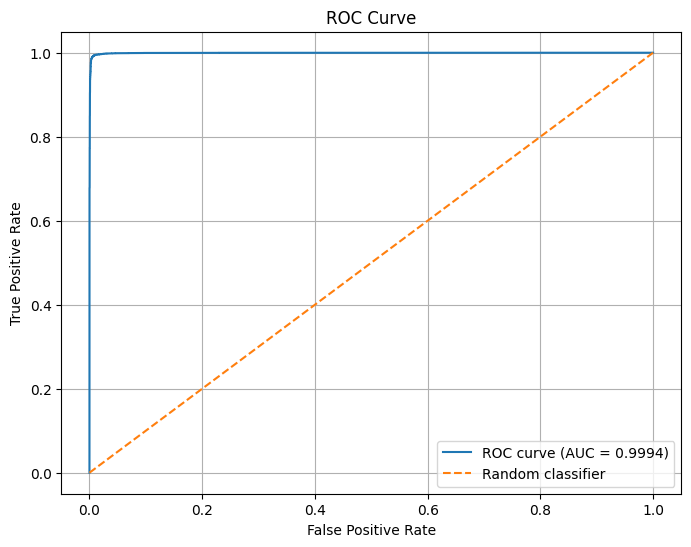

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    true_labels,
    probabilities
)

# Calculate AUC
auc_score = roc_auc_score(
    true_labels,
    probabilities
)

print(f"ROC-AUC: {auc_score:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC curve (AUC = {auc_score:.4f})"
)

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [ ]:
!nvidia-smi

Tue Aug  4 19:51:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P0             50W /  400W |    5046MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [20]:
print(next(model.parameters()).device)


cuda:0


In [21]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

accuracy = accuracy_score(
    true_labels,
    predictions
)

f1 = f1_score(
    true_labels,
    predictions
)

print("Accuracy:", accuracy)
print("F1 Score:", f1)

print(
    classification_report(
        true_labels,
        predictions
    )
)
# Confusion Matrix
cm = confusion_matrix(
    true_labels,
    predictions
)

print("\nConfusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

Accuracy: 0.9925831065578145
F1 Score: 0.9927014964557627
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9212
           1       0.99      0.99      0.99      9529

    accuracy                           0.99     18741
   macro avg       0.99      0.99      0.99     18741
weighted avg       0.99      0.99      0.99     18741


Confusion Matrix:
[[9149   63]
 [  76 9453]]

True Negatives : 9149
False Positives: 63
False Negatives: 76
True Positives : 9453


In [28]:
import json

records = []
dict = {}
#with open("/content/drive/MyDrive/capstone_usable_qa_data/retriever_output.txt", "r") as f:
with open("retrieved_results1.jsonl", "r") as f:
  dict = {}
  for line in f:
    print(line)
    j_obj = json.loads(line)
    dict["score"] = j_obj["score"]
    dict["reference"] = j_obj["reference"]
    dict["chunk_id"] = j_obj["chunk_id"]
    records.append(dict)


{"score": "0.6725", "reference": "Section:7,Management's Discussion and Analysis of Financial Condition and Results of Operations (MD&A)\nCompanyName:Apple\nTicker:AAPL\nYear:2025\nApple Inc. | 2025 Form 10-K | 22 Products and Services Performance The following table shows net sales by category for 2025, 2024 and 2023 (dollars in millions): ##TABLE_START 2025 Change 2024 Change 2023 iPhone $ 209,586 4 % $ 201,183 &#8212; % $ 200,583 Mac 33,708 12 % 29,984 2 % 29,357 iPad 28,023 5 % 26,694 (6) % 28,300 Wearables, Home and Accessories 35,686 (4) % 37,005 (7) % 39,845 Services (1)\n", "chunk_id": "AAPL-7-2025-17"}{"score": "0.6604", "reference": "Section:7,Management's Discussion and Analysis of Financial Condition and Results of Operations (MD&A)\nCompanyName:Apple\nTicker:AAPL\nYear:2025\nServices (1) 109,158 14 % 96,169 13 % 85,200 Total net sales $ 416,161 6 % $ 391,035 2 % $ 383,285 ##TABLE_END (1) Services net sales include amortization of the deferred value of services bundled in t

JSONDecodeError: Extra data: line 1 column 619 (char 618)

Read Results From Retriever

In [ ]:
records = []
#with open("/content/drive/MyDrive/capstone_usable_qa_data/retriever_output.txt", "r") as f:
with open("retrieved_results1.jsonl", "r") as f:
  j_obj = json.loads(line)
  records.append(j_obj)
 """ dict = {}
  i = 0
  #k = 0
  #while k < 10:
  for line in f:
      #print (f"is {i} and line is {line}")
      if i == 1:
        dict["ticker"] = line

      elif i == 2:
        dict["section"] = line

      elif i == 3:
        dict["year"] = line

      elif i == 4:
        dict["reference"] = line
        #print(f"dict {dict}")
        records.append(dict)
        dict = {}
        i = -2
      i = i + 1
    #k = k + 1
  print(f"{records[0]}")"""

RE-Rank

In [ ]:
import torch

#question = "What supplier risks does NVIDIA face in 2025?"
question = "What are Apple's top selling products?"
reranked = []

model.eval()

for chunk in records:
    #print (f"Ref: {chunk["reference"]}")
    inputs = tokenizer(
        question,
        chunk["reference"],
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    # Move tensors to GPU
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits

    probability = torch.softmax(
        logits,
        dim=1
    )[0, 1].item()

    reranked.append({
        "score": probability,
        "chunk": chunk
    })

Sort

In [ ]:
reranked.sort(
    key=lambda x: x["score"],
    reverse=True
)

top5 = reranked[:5]

Show Evidence

In [ ]:
for r in top5:

    print("=" * 80)

    print("Score:", r["score"])

    #print("Ticker:", r["chunk"]["ticker"])

    #print("Section:", r["chunk"]["section"])

    print(r["chunk_id"])

    print(r["chunk"]["reference"][:400])

Score: 0.631367564201355
Ticker: NVDA

Section: 1A

. These risks may also increase when our products are introduced into new devices, markets, technologies and applications, or new versions are released, and when we rely on partners to supply and manu

Score: 0.6045154929161072
Ticker: NVDA

Section: 1A

Item 1A: Risk Factors The following risk factors could materially and adversely affect our business, financial condition or results of operations and cause reputational harm, and should be carefully c

Score: 0.6045154929161072
Ticker: NVDA

Section: 1A

Item 1A: Risk Factors The following risk factors could materially and adversely affect our business, financial condition or results of operations and cause reputational harm, and should be carefully c

Score: 0.5830297470092773
Ticker: NVDA

Section: 1A

You should consider each of the following factors in evaluating our business and our prospects. However, the risks and uncertainties described below are not the only ones we face. Add

Credentials To Call Vertex API For Q&A Prompt

In [ ]:
#keep
import os

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = \
    "./triple-mountain-483601-k3-3a823d61bdb7.json"

Create Gemini Prompt

In [ ]:
evidence = ""

for i, r in enumerate(top5):

    chunk = r["chunk"]

    evidence += f"""

Evidence {i+1}

Company: {chunk['ticker']}

Section: {chunk['section']}

Confidence: {r['score']:.3f}

{chunk['reference']}

----------------------------------------

"""

prompt = """Question:
What supplier risks does NVIDIA face? Evidence:"""f""" {evidence}""""""Answer using only the evidence above. Cite the section and the company"""

Return Response

In [ ]:
#keep
!pip install google-genai

from google import genai

from pydantic import BaseModel
client = genai.Client(
    vertexai=True,
    project="triple-mountain-483601-k3",
    location="us-central1"
    )
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt
)

print(response.text)

NVIDIA faces supplier risks because it relies on partners to supply and manufacture (NVDA, Section 1A). These risks may also increase when their products are introduced into new devices, markets, technologies and applications, or when new versions are released (NVDA, Section 1A).
